# Part Å: SciML parameter estimation with PEtab.jl

Hybrid scientific machine learning (SciML) combines mechanistic ODE models with machine learning models. PEtab.jl supports three SciML problem types:

1. An ML model embedded in the ODE dynamics. This includes both Universal Differential Equations (UDEs) and Neural ODEs.
2. An ML model in the observable formula that maps model output to measurement data.
3. A pre-simulation ML model that maps input data, such as high-dimensional images, to ODE parameters and/or initial conditions before simulation.

![Hybrid types](assets/hybrid_types.svg)


This notebook focuses on the first case: defining via Catalyst and training a UDE. As a first running example, we use the following two-state ODE model:

```math
\begin{align*}
\frac{\mathrm{d}X}{\mathrm{d}t} &= \frac{vY^n}{Y^n + K^n} - dX \\
\frac{\mathrm{d}Y}{\mathrm{d}t} &= X - dY
\end{align*}
```

with initial conditions

```math
X(t_0) = 2.0, \quad Y(t_0) = 0.1.
```

To turn this into a UDE, we assume the production term for $X$ is unknown and replace it by a neural network:

```math
\begin{align*}
\frac{\mathrm{d}X}{\mathrm{d}t} &= \mathrm{NN}_1([Y]; \text{theta}) - dX \\
\frac{\mathrm{d}Y}{\mathrm{d}t} &= X - dY
\end{align*}
```

where $\mathrm{NN}$ is a feed-forward neural network with parameters `theta` and
input $Y$.

## Part 6.1: Defining a SciML PEtab problem

A SciML `PEtabODEProblem` is constructed largely in the same way as for a purely mechanistic model. The difference is that one or more Lux.jl neural networks are defined and embedded into the Catalyst model.

### Part 6.1.1: Defining the ML model

PEtab.jl currently supports ML models defined with [Lux.jl](https://lux.csail.mit.edu/stable/). To be compatible with PEtab.jl, the Lux model must define a set of layers with unique names together with a forward pass. This is most easily done with `Lux.Chain`:

In [19]:
using Lux
lux_model = Lux.Chain(
    Lux.Dense(1 => 3, Lux.softplus, use_bias = false),
    Lux.Dense(3 => 3, Lux.softplus, use_bias = false),
    Lux.Dense(3 => 1, Lux.softplus, use_bias = false),
)

Chain(
    layer_1 = Dense(1 => 3, softplus, use_bias=false),  # 3 parameters
    layer_2 = Dense(3 => 3, softplus, use_bias=false),  # 9 parameters
    layer_3 = Dense(3 => 1, softplus, use_bias=false),  # 3 parameters
)         # Total: 15 parameters,
          #        plus 0 states.

### Part 6.1.2: Defining the UDE model

A UDE dynamic model is most easily created using ModelingToolkitNeuralNets. The
first step is to create a symbolic neural network from the Lux model:

In [20]:
using ModelingToolkitNeuralNets
@SymbolicNeuralNetwork NN, theta = lux_model

(NN⋆, theta[1:15])

Here `theta` is the network parameter vector, and `NN` is the neural network
that can be embedded into a Catalyst model:

In [21]:
using Catalyst

A(z) = NN([z], theta)
rn_ude = @reaction_network begin
    @species begin
        X(t) = 2.0
        Y(t) = 0.1
    end
    @parameters d
    # Reactions
    $A(Y)[1], 0 --> X
    d, X --> 0
    1.0, X --> X + Y
    d, Y --> 0
end

Model ##ReactionSystem#314:
Unknowns (2): see unknowns(##ReactionSystem#314)
  X(t)
  Y(t)
Parameters (3): see parameters(##ReactionSystem#314)
  d
  NN
  theta

### Part 6.1.3: Parameters to estimate

A `PEtabMLParameter` must be defined for each `MLModel` whose parameters should be estimated. Therefore, when specifying the parameters to estimate, both mechanistic parameters (`PEtabParameter`) and ML parameters (`PEtabMLParameter`) must be declared:

In [22]:
using PEtab
pest = [
    PEtabMLParameter(:theta),
    PEtabParameter(:d; scale = :log10)
]

2-element Vector{Any}:
 PEtabMLParameter theta: estimate
 PEtabParameter d: estimate (scale = log10, bounds = [1.0e-03, 1.0e+03])

### Part 6.1.4: Measurements and observables

Measurements and observables are defined in the same way as for a mechanistic `PEtabODEProblem`. For this example, we simulate data and split it into training and validation sets:

In [23]:
using DataFrames, OrdinaryDiffEqTsit5, StableRNGs
using ModelingToolkitBase
using ModelingToolkitBase: t_nounits as t, D_nounits as D
rng = StableRNGs.StableRNG(3)

@variables X(t) Y(t)
@parameters v K n d
eqs_true = [
    D(X) ~ v * (Y^n) / (K^n + Y^n) - d*X
    D(Y) ~ X - d*Y
]
@mtkcompile sys_true = System(eqs_true, t)
u0 = [X => 2.0, Y => 0.1]
ps_true = [v => 1.1, K => 2.0, n => 3.0, d => 0.5]

tend = 66.0
ode_true = ODEProblem(sys_true, [u0; ps_true], (0.0, tend))
sol = solve(
    ode_true, Tsit5(); abstol = 1e-8, reltol = 1e-8, saveat = 0:2:tend
)
data_X = sol[1, :] .+ randn(rng, length(sol.t)) .* 0.5
data_Y = sol[2, :] .+ randn(rng, length(sol.t)) .* 0.7
df1 = DataFrame(obs_id = "obs_X", time = sol.t, measurement = data_X)
df2 = DataFrame(obs_id = "obs_Y", time = sol.t, measurement = data_Y)
measurements = vcat(df1, df2)

Row,obs_id,time,measurement
,String,Float64,Float64
1,obs_X,0.0,2.10367
2,obs_X,2.0,0.860251
3,obs_X,4.0,0.719844
4,obs_X,6.0,0.704974
5,obs_X,8.0,0.911663
6,obs_X,10.0,0.300716
7,obs_X,12.0,0.945423
8,obs_X,14.0,1.73798
9,obs_X,16.0,0.818048


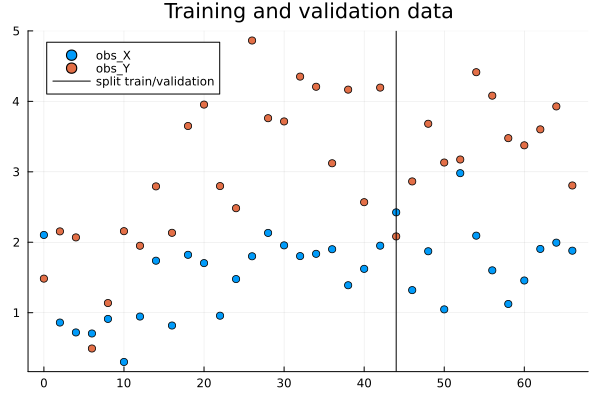

In [24]:
using Plots
measurements_train = filter(row -> row.time <= 44.0, measurements)
measurements_val = filter(row -> row.time > 44.0, measurements)
scatter(
    measurements.time, measurements.measurement, group = measurements.obs_id,
    title = "Training and validation data"
)
vline!(
    [44.0], label = "split train/validation", color = "black"
)

Since both `X` and `Y` are assumed to be measured, the observables are:

In [25]:
observables = [
    PEtabObservable(:obs_X, :X, 0.5),
    PEtabObservable(:obs_Y, :Y, 0.7),
]

2-element Vector{PEtabObservable}:
 PEtabObservable obs_X: data ~ Normal(μ=X, σ=0.5)
 PEtabObservable obs_Y: data ~ Normal(μ=Y, σ=0.7)

### Part 6.1.5: Build the parameter estimation problem

Given training and validation data, separate `PEtabODEProblem`s can be created for the training and validation objectives:

In [26]:
model_train = PEtabModel(rn_ude, observables, measurements_train, pest)
model_val = PEtabModel(rn_ude, observables, measurements_val, pest)
prob_train = PEtabODEProblem(model_train)
prob_val = PEtabODEProblem(model_val)
describe(prob_train)

PEtabODEProblem ReactionSystemModel
Problem statistics
  Parameters to estimate: 16
  ODE: 2 states, 16 parameters
  Observables: 2
  Simulation conditions: 1

ML models
  theta: (mode=simulation, parameters=15)

Configuration
  Gradient method: ForwardDiff
  Hessian method: ForwardDiff
  ODE solver (nllh): Tsit5 (abstol=1.0e-08, reltol=1.0e-08, maxiters=1e+04)
  ODE solver (grad): Tsit5 (abstol=1.0e-08, reltol=1.0e-08, maxiters=1e+04)

## Part 6.2: Model training (parameter estimation)

SciML problems can be trained with the same methods used for purely mechanistic models, such as multistart local optimization with a BFGS-based optimizer. In practice, training often works better with optimizers commonly used in machine learning, such as Adam. 

Adam can easily be used together with `calibrate`:

In [27]:
using StableRNGs
rng = StableRNGs.StableRNG(42) # for reproducibility
x0 = get_startguesses(rng, prob_train, 1)

using Optimisers
learning_rate = 1e-3
res = calibrate(
    prob_train, x0, Optimisers.Adam(learning_rate);
    options = OptimisersOptions(iterations = 7500),
)

PEtabOptimisationResult
  min(f)                = 3.88e+01
  Parameters estimated  = 16
  Optimiser iterations  = 7500
  Runtime               = 9.5e+01s
  Optimiser algorithm   = Adam


By plotting the fitted model, we see that it fits both the training and validation data well:

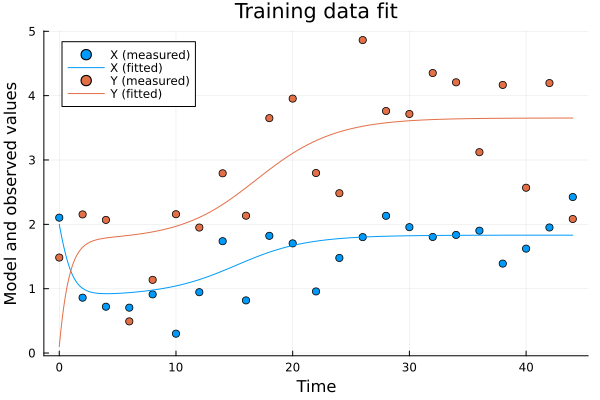

In [28]:
plot(res, prob_train, title = "Training data fit")

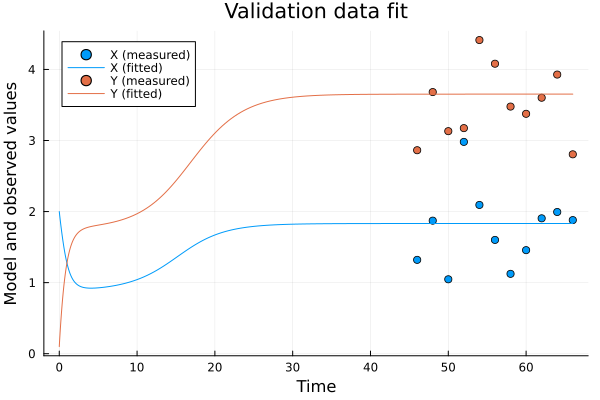

In [29]:
plot(res, prob_val, title = "Validation data fit")

As one of many possible downstream analyses, we can compare the learned neural network to
the true function it aims to approximate:

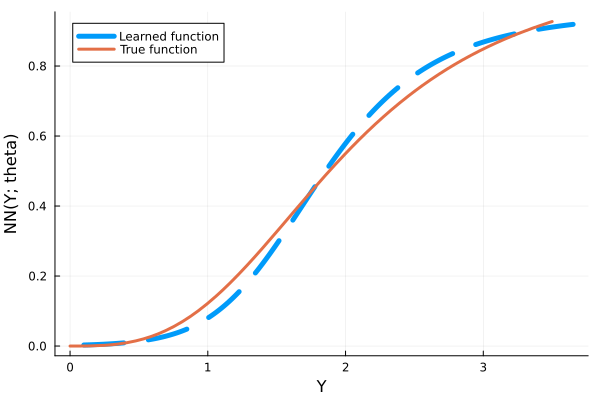

In [30]:
plot(
    res, prob_train; plot_type = :best_function, 
    label = "Learned function", linestyle = :dash, lw = 5
)
# Overlay the true function
true_func(y) = 1.1 * (y^3) / (2^3 + y^3)
plot!(true_func, 0.0, 3.5; label = "True function", lw = 3)

By running a multistart calibration, we can overlay the results from multiple
fits to assess uncertainty in the learned function:

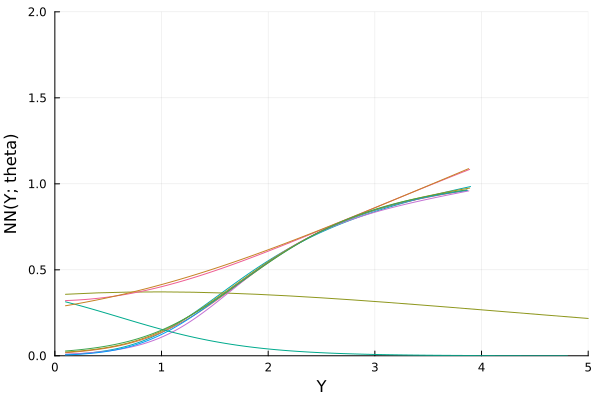

In [31]:
# Importing pre-computed solution to save time :)
path_res = joinpath("assets", "sciml_plotting")
res_ms = PEtabMultistartResult(path_res)

plot(
    res_ms, prob_train; plot_type = :function_ensemble,
    xlimit = (0.0, 5.0), ylimit = (0.0, 2.0)
)

We can also restrict this to the fits that reached a good loss value:

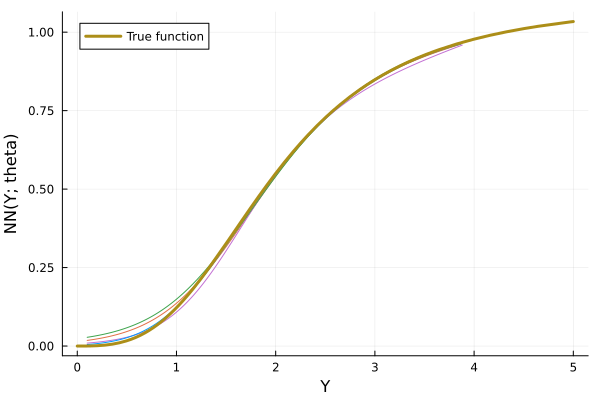

In [32]:
plot(
    res_ms, prob_train; plot_type = :function_ensemble,
    loss_thres = res_ms.fmin + abs(res_ms.fmin) / 2
)
plot!(true_func, 0.0, 5.0; label = "True function", lw = 3)

## Part 6.3: Training strategies

Adam works well for simpler models, but is often insufficient for harder-to-train problems. Several specialized training strategies have been developed to address this, and PEtab.jl provides access to them through [PEtabTraining.jl](https://github.com/sebapersson/PEtabTraining.jl). Here we compare plain Adam training against curriculum learning, and curriculum multiple shooting.

As a working example we use the Lotka–Volterra system,

```math
\begin{align*}
\frac{\mathrm{d}x}{\mathrm{d}t} &= \alpha x - \beta x y \\
\frac{\mathrm{d}y}{\mathrm{d}t} &= \delta x y - \gamma y
\end{align*}
```

Its oscillatory dynamics make it a challenging training target. We fit the full dynamics with a neural ODE, replacing the entire right-hand side by a neural network:

```math
\frac{\mathrm{d}}{\mathrm{d}t}
\begin{bmatrix} x \\ y \end{bmatrix}
= \mathrm{NN}\!\left( \begin{bmatrix} x \\ y \end{bmatrix};\ \theta \right)
```

with network parameters $\theta$. For training, we generate both simulated training and validation data:

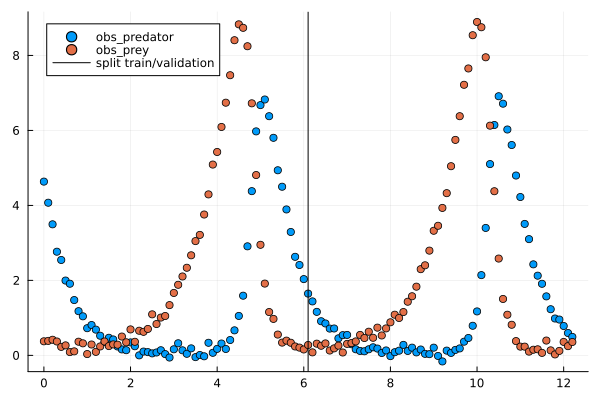

In [33]:
using Lux, ModelingToolkitBase, ModelingToolkitNeuralNets, PEtab
using ModelingToolkitBase: t_nounits as t, D_nounits as D

# Neural network structure
lux_model = Lux.Chain(
    Lux.Dense(2 => 5, Lux.swish),
    Lux.Dense(5 => 5, Lux.swish),
    Lux.Dense(5 => 2),
)

# Defining the neural ODE
@SymbolicNeuralNetwork NN, theta = lux_model
@variables prey(t)=0.44249296 predator(t)=4.6280594
eqs = [
    D(prey) ~ NN([prey, predator], theta)[1]
    D(predator) ~ NN([prey, predator], theta)[2]
]
@mtkcompile sys_node = System(eqs, t)

parameters_est = [PEtabMLParameter(:theta)]

obs = [
    PEtabObservable(:obs_prey, :prey, 1.0),
    PEtabObservable(:obs_predator, :predator, 1.0)
]

using DataFrames, StableRNGs, OrdinaryDiffEqTsit5
rng = StableRNGs.StableRNG(42)

function lv_ode!(du, u, p, t)
    prey, predator = u
    du[1] = p.alpha * prey - p.beta * prey * predator
    du[2] = p.gamma * prey * predator - p.delta * predator
    return nothing
end

u0 = [0.44249296, 4.6280594]
p_true = (alpha = 1.3, beta = 0.9, gamma = 0.8, delta = 1.8)
lv_prob = ODEProblem(lv_ode!, u0, (0.0, 13.0), p_true)
sol = solve(lv_prob, Tsit5(); abstol = 1e-8, reltol = 1e-8, saveat = 0:0.1:12.2)

obs_prey = sol[1, :] .+ 0.1 .* randn(rng, length(sol.t))
obs_predator = sol[2, :] .+ 0.1 .* randn(rng, length(sol.t))

df_prey = DataFrame(
    time = sol.t, measurement = obs_prey, obs_id = "obs_prey"
)
df_predator = DataFrame(
    time = sol.t, measurement = obs_predator, obs_id = "obs_predator"
)
df_m = vcat(df_prey, df_predator)

t_split = 6.1
df_train = filter(row -> row.time <= t_split, df_m)
df_val = filter(row -> row.time > t_split, df_m)

using Plots
scatter(df_m.time, df_m.measurement, group = df_m.obs_id)
vline!(
    [t_split], label = "split train/validation", color = "black"
)

Given training/validation data, separate `PEtabODEProblem`s can be created:

In [34]:
model_train = PEtabModel(sys_node, obs, df_train, parameters_est)
model_val = PEtabModel(sys_node, obs, df_val, parameters_est)
prob_train = PEtabODEProblem(model_train)
prob_val = PEtabODEProblem(model_val)

PEtabODEProblem ODESystemModel: 57 parameters to estimate
(for more statistics, call `describe(petab_prob)`)

### Part 6.3.1: Generate start guesses

Regardless of the training strategy, optimization needs an initial guess. For SciML problems such as neural ODEs and UDEs, training is often more stable when the network is initialized with small weights and biases; otherwise the initial dynamics can be hard to simulate. Custom weight and bias initializers can be passed to `get_startguesses`:

In [35]:
rng = StableRNGs.StableRNG(12) # for reproducibility
# default is glorot_normal(; gain = 1.2)
x0 = get_startguesses(
    rng, prob_train, 1; init_bias = Lux.zeros64,
    init_weight = glorot_normal(; gain = 0.2),
)

ComponentVector{Float64}(theta = (layer_1 = (weight = [0.007468103431165218 -0.09022583067417145; 0.015104258432984352 0.015432372689247131; … ; 0.08997608721256256 0.10592770576477051; -0.019743818789720535 0.08177052438259125], bias = [0.0, 0.0, 0.0, 0.0, 0.0]), layer_2 = (weight = [0.008138655684888363 -0.08641810715198517 … -0.004977911710739136 -0.11282863467931747; 0.07290863990783691 -0.02770441398024559 … -0.01894454099237919 0.05518005043268204; … ; 0.0403289720416069 0.17698456346988678 … -0.007785269059240818 0.06936381757259369; 0.013333163224160671 -0.0378882922232151 … 0.09529168903827667 -0.05527111142873764], bias = [0.0, 0.0, 0.0, 0.0, 0.0]), layer_3 = (weight = [0.07470835745334625 -0.13311609625816345 … 0.0012523462064564228 0.011729035526514053; -0.13360300660133362 -0.02292529121041298 … -0.1313692182302475 0.1860201209783554], bias = [0.0, 0.0])))

### Part 6.3.2: Plain Adam training

Given an initial guess, the objective and its gradient are available as `prob_train.nllh(x)` and `prob_train.grad(x)`, which we use to write a training loop:

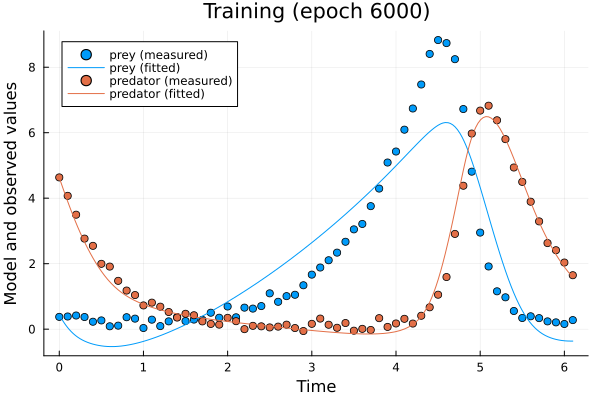

prob_train.nllh(x) = 143.46483606491765


143.46483606491765

In [36]:
using Optimisers, IJulia

x = deepcopy(x0)
learning_rate = 1e-3
state = Optimisers.setup(Adam(learning_rate), x)

trace_adam = Float64[]
n_epochs = 6000
plot_every = 100            # redraw the fit every this many epochs

for epoch in 1:n_epochs
    g = prob_train.grad(x)
    state, x = Optimisers.update(state, x, g)

    if epoch % 25 == 0 || epoch == 1
        nllh_train = prob_train.nllh(x)
        push!(trace_adam, nllh_train)
    end

    # Live-update the fit against the training and validation data
    if epoch % plot_every == 0 || epoch == 1
        p1 = plot(x, prob_train; title = "Training (epoch $epoch)")
        IJulia.clear_output(true)                    # replace the previous frame
        display(p1)
    end
end
@show prob_train.nllh(x)

Plotting the end result shows a reasonable fit, though there is still room for improvement, especially on the validation data:

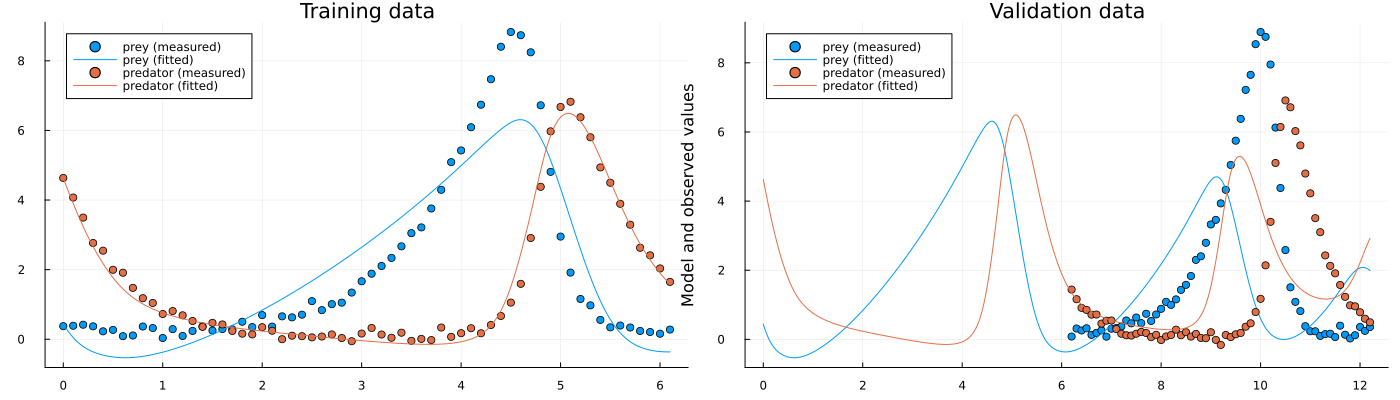

In [37]:
p1 = plot(x, prob_train)
title!(p1, "Training data")
p2 = plot(x, prob_val)
title!(p2, "Validation data")
plot(p1, p2, layout = (1, 2), size = (1400, 400))

### Part 6.3.3: Curriculum learning

Curriculum learning is a strategy in which the difficulty of the training problem is increased gradually across a sequence of stages. For a `PEtabODEProblem`, this is done by first training on a subset of the measurement time points and then progressively including more, until the full dataset is used.

![Curriculum learning](assets/cl_illustration.png)

With [PEtabTraining.jl](https://github.com/sebapersson/PEtabTraining.jl), a 9-stage curriculum over time is created as:

In [38]:
using PEtabTraining
prob_cl = PEtabClProblem(prob_train, SplitTime(9))
describe(prob_cl)

PEtabClProblem ODESystemModel
Problem statistics
  Parameters to estimate: 57
  ODE: 2 states, 57 parameters
  Observables: 2
  Simulation conditions: 1

Curriculum statistics (9 stages)
  Stage 1: tspan [0.0, 0.6]
           fraction (obs/cond): 1.0/1.0
  Stage 2: tspan [0.0, 1.3]
           fraction (obs/cond): 1.0/1.0
  Stage 3: tspan [0.0, 2.0]
           fraction (obs/cond): 1.0/1.0
  Stage 4: tspan [0.0, 2.7]
           fraction (obs/cond): 1.0/1.0
  Stage 5: tspan [0.0, 3.4]
           fraction (obs/cond): 1.0/1.0
  Stage 6: tspan [0.0, 4.1]
           fraction (obs/cond): 1.0/1.0
  Stage 7: tspan [0.0, 4.8]
           fraction (obs/cond): 1.0/1.0
  Stage 8: tspan [0.0, 5.5]
           fraction (obs/cond): 1.0/1.0
  Stage 9: tspan [0.0, 6.1]
           fraction (obs/cond): 1.0/1.0

`describe(prob_cl)` reports per-stage statistics, such as the fraction of observables and simulation conditions included at each stage. As a rule of thumb, curriculum learning works best when each stage covers most observables and conditions, so the training objective changes gradually across stages.

The stage-specific problems are stored in `prob_cl.petab_problems` as separate `PEtabODEProblem`s, which we use to write a training loop:

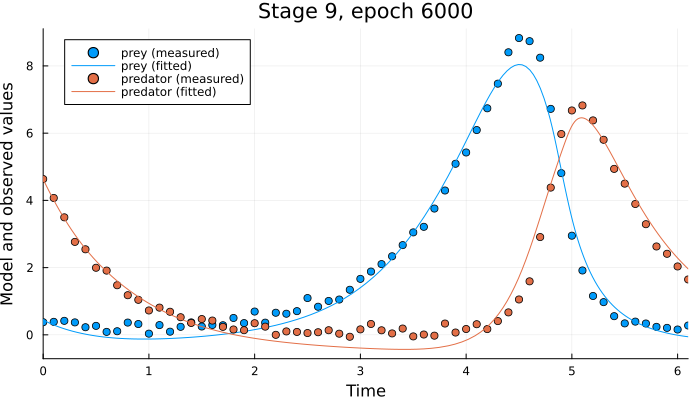

prob_train.nllh(x_cl_fit) = 121.50987379521375


121.50987379521375

In [39]:
using Optimisers, IJulia

epochs_per_stage = allocate_cl_epochs(6000, 9, 1 / 3.0)

x = deepcopy(x0)
learning_rate = 1.0e-3
state = Optimisers.setup(Adam(learning_rate), x)

trace_cl = Float64[]
plot_every = 100
t_lo, t_hi = extrema(df_train.time)

for (stage, epochs) in epochs_per_stage
    prob_stage = prob_cl.petab_problems[stage]
    for epoch in epochs
        g = prob_stage.grad(x)
        state, x = Optimisers.update(state, x, g)

        if epoch % 25 == 0 || epoch == 1
            nllh_train = prob_stage.nllh(x)
            push!(trace_cl, nllh_train)
        end

        # Live-update the fit against the current stage's data only
        if epoch % plot_every == 0
            p = plot(
                x, prob_stage; title = "Stage $stage, epoch $epoch",
                size = (700, 400)
            )
            xlims!(p, (t_lo, t_hi))
            IJulia.clear_output(true)
            display(p)
        end
    end
end
x_cl_fit = deepcopy(x)
@show prob_train.nllh(x_cl_fit)

Plotting the fit shows an improvement compared to plain Adam:

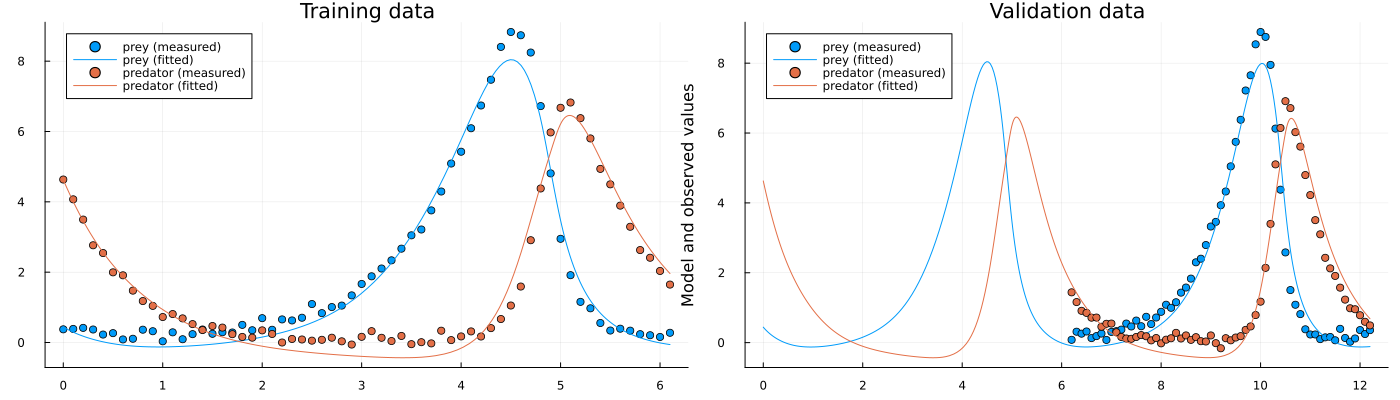

In [40]:
p1 = plot(x_cl_fit, prob_train)
title!(p1, "Training data")
p2 = plot(x_cl_fit, prob_val)
title!(p2, "Validation data")
plot(p1, p2, layout = (1, 2), size = (1400, 400))

### Part 6.3.4: Curriculum multiple shooting

Curriculum multiple shooting combines multiple shooting with a curriculum
schedule. Training starts from a multiple-shooting formulation and progressively
merges adjacent windows until the original single-window problem is recovered.

![Curriculum multiple shooting](assets/cms_illustration.png)

As an example, a 5-stage curriculum multiple-shooting problem is created as:

In [41]:
prob_cl_ms = PEtabClMsProblem(prob_train, SplitTime(5))
describe(prob_cl_ms)

PEtabClMsProblem ODESystemModel
Problem statistics
  Parameters to estimate: 57
  ODE: 2 states, 57 parameters
  Observables: 2
  Simulation conditions: 1

Curriculum statistics (5 stages)
  Window penalty λ = 1.0e+00
  Stage 1: window tspans [0, 1.3], [1.3, 2.6], [2.6, 3.8], [3.8, 5], [5, 6.1]
  Stage 2: window tspans [0, 2.6], [1.3, 3.8], [2.6, 5], [3.8, 6.1]
  Stage 3: window tspans [0, 3.8], [1.3, 5], [2.6, 6.1]
  Stage 4: window tspans [0, 5], [1.3, 6.1]
  Stage 5: original problem

Two key tuning parameters are the window penalty and the initialization of window initial states, the same as for plain multiple shooting as in the first stage, we are training just a multiple shooting objective. Both can be set with:

In [42]:
set_ms_window_penalty!(prob_cl_ms, 1000.0)
# Initialize window states for stage 1
x_cl_ms = get_x(prob_cl_ms.petab_problems[1])
set_u0_ms_windows!(x_cl_ms, prob_cl_ms, 1; init = MsInitConstant(0.01))

`PEtabClMsProblem` stores the stage problems in `prob_cl_ms.petab_problems` as separate `PEtabODEProblem`s, which can be used to write a training loop. When moving between stages, `map_x_stage` maps parameters to the next stage (the window count changes, so the window initial states must be remapped). For example:

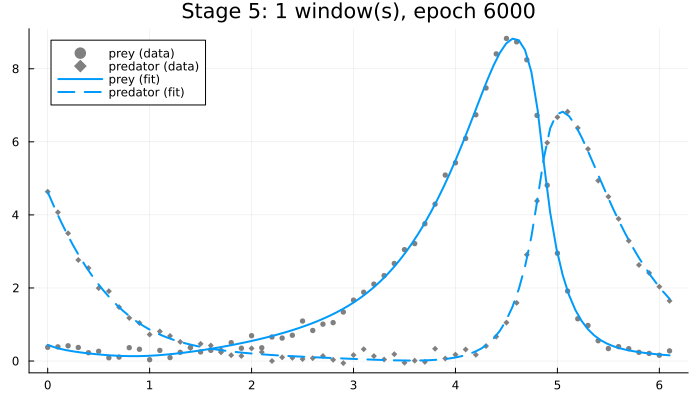

prob_train.nllh(x_cms_fit) = 114.71733700026434


114.71733700026434

In [43]:
epochs_per_stage = allocate_cl_epochs(6000, 5, 1 / 3.0)
learning_rate = 1.0e-3
plot_every = 100

# Helper function for plotting the fit, not required for actual training
function plot_ms_fit(x, prob_stage, stage, epoch)
    cond_ids = prob_stage.model_info.simulation_info.conditionids[:experiment]
    nwin = length(cond_ids)

    prey_d = filter(r -> r.obs_id == "obs_prey", df_train)
    pred_d = filter(r -> r.obs_id == "obs_predator", df_train)
    p = scatter(
        prey_d.time, prey_d.measurement; color = :gray, markershape = :circle,
        markersize = 3, markerstrokewidth = 0, label = "prey (data)",
        size = (700, 400), title = "Stage $stage: $nwin window(s), epoch $epoch"
    )
    scatter!(
        p, pred_d.time, pred_d.measurement; color = :gray, markershape = :diamond,
        markersize = 3, markerstrokewidth = 0, label = "predator (data)"
    )

    for (k, cond) in enumerate(cond_ids)
        sol = get_odesol(x, prob_stage; condition = cond)
        ts  = range(first(sol.t), last(sol.t); length = 100)
        plot!(
            p, ts, [sol(t)[1] for t in ts]; color = k, lw = 2, linestyle = :solid,
            label = k == 1 ? "prey (fit)" : ""
        )
        plot!(
            p, ts, [sol(t)[2] for t in ts]; color = k, lw = 2, linestyle = :dash,
            label = k == 1 ? "predator (fit)" : ""
        )
    end
    return p
end

x_cl_ms[keys(x0)] .= x0
trace_cl_ms = Float64[]
for (stage, epochs) in epochs_per_stage
    if stage > 1
        x_cl_ms = map_x_stage(x_cl_ms, prob_cl_ms, stage - 1, stage)
    end

    prob_stage = prob_cl_ms.petab_problems[stage]
    state = Optimisers.setup(Adam(learning_rate), x_cl_ms)

    for epoch in epochs
        g = prob_stage.grad(x_cl_ms)
        state, x_cl_ms = Optimisers.update(state, x_cl_ms, g)

        # Save training trace on the original objective for comparability
        if epoch % 25 == 0 || epoch == 1
            x = x_cl_ms[keys(x0)]
            push!(trace_cl_ms, prob_train.nllh(x))
        end

        # Live-update the multiple-shooting fit (windows drawn separately)
        if epoch % plot_every == 0
            IJulia.clear_output(true)
            display(plot_ms_fit(x_cl_ms, prob_stage, stage, epoch))
        end
    end
end
x_cms_fit = deepcopy(x_cl_ms[keys(x0)])
@show prob_train.nllh(x_cms_fit)

Plotting the result shows an excellent fit:

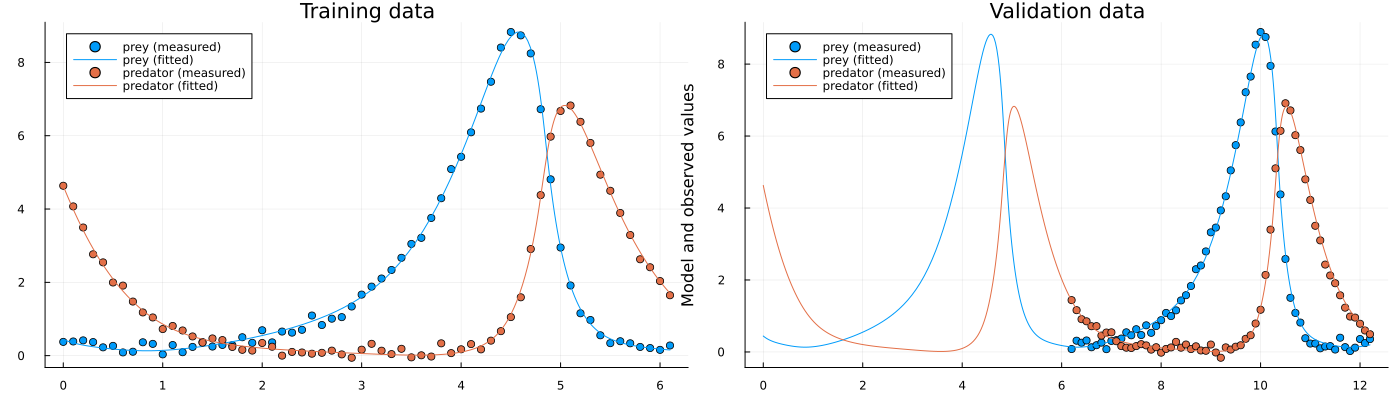

In [44]:
p1 = plot(x_cms_fit, prob_train)
title!(p1, "Training data")
p2 = plot(x_cms_fit, prob_val)
title!(p2, "Validation data")
plot(p1, p2, layout = (1, 2), size = (1400, 400))

## Part 6.4: Bonus: The PEtab-SciML standard format

PEtab.jl SciML functionality is built around the [PEtab-SciML standard](https://github.com/PEtab-dev/petab_sciml) for parameter estimating SciML problems. Models in this format can be imported directly into PEtab.jl. For example, the LV-model we worked with above can be imported as:

In [45]:
using PEtab
path_yaml = joinpath(@__DIR__, "assets", "lv_ude", "problem.yaml")
ml_models = MLModels(path_yaml)
petab_model = PEtabModel(path_yaml; ml_models = ml_models)
petab_prob = PEtabODEProblem(petab_model)
describe(petab_prob)

PEtabODEProblem lv_ude
Problem statistics
  Parameters to estimate: 54
  ODE: 2 states, 55 parameters
  Observables: 2
  Simulation conditions: 1

ML models
  net1: (mode=simulation, parameters=51)

Configuration
  Gradient method: ForwardDiff
  Hessian method: ForwardDiff
  ODE solver (nllh): Tsit5 (abstol=1.0e-08, reltol=1.0e-08, maxiters=1e+04)
  ODE solver (grad): Tsit5 (abstol=1.0e-08, reltol=1.0e-08, maxiters=1e+04)

## Where to go next

This notebook showed how to define a SciML `PEtabODEProblem`. For additional features, including SciML problem types beyond UDEs, see the following tutorials:

- [ML models in observables](https://sebapersson.github.io/PEtab.jl/stable/tutorials/sciml/observable): Define an ML model in a `PEtabObservable` formula, for example to correct model misspecification.
- [Pre-simulation ML models](https://sebapersson.github.io/PEtab.jl/stable/tutorials/sciml/pre_simulate): Define ML models that map input data, such as high-dimensional images, to ODE parameters or initial conditions before simulation.
- [Importing PEtab SciML](https://sebapersson.github.io/PEtab.jl/stable/tutorials/sciml/standard_format): Import problems in the PEtab-SciML standard format.